In [23]:
from pathlib import Path
import os

import certifi
import requests
import geopandas as gpd 
import matplotlib.pyplot as plt

DATA_PATH = Path(
    "../data/processed/dnr_up_hiking_trails_grouped.parquet"
)

trails = gpd.read_parquet(DATA_PATH)

In [24]:
COUNTY_QUERY_URL = (
    "https://imagery.michigan.gov/server/rest/services/"
    "CountiesAndMuniBoundaries/MapServer/1/query"
)

query_parameters = {
    "where": "1=1",
    "outFields": "NAME,PENINSULA",
    "returnGeometry": "true",
    "outSR": "4326",
    "f": "geojson",
}

response = requests.get(
    COUNTY_QUERY_URL,
    params=query_parameters,
    timeout=60,
    verify=certifi.where(),
)

response.raise_for_status()

county_geojson = response.json()

if not county_geojson.get("features"):
    raise RuntimeError("The county service returned no features.")

counties = gpd.GeoDataFrame.from_features(
    county_geojson["features"],
    crs="EPSG:4326",
)

print(f"County rows: {len(counties):,}")
print(f"County CRS: EPSG:{counties.crs.to_epsg()}")
counties.head()

County rows: 83
County CRS: EPSG:4326


,geometry,NAME,PENINSULA
0,"POLYGON ((-83.88701 44.54217, -83.88699 44.540...",Alcona,lower
1,"MULTIPOLYGON (((-86.61526 46.28671, -86.61527 ...",Alger,upper
2,"POLYGON ((-85.54343 42.42905, -85.54343 42.430...",Allegan,lower
3,"MULTIPOLYGON (((-83.3434 44.88554, -83.34361 4...",Alpena,lower
4,"MULTIPOLYGON (((-84.84877 44.93222, -84.84878 ...",Antrim,lower


In [25]:
up_counties = counties[
    counties["PENINSULA"]
    .astype(str)
    .str.contains("Upper", case=False, na=False)
].copy()

if up_counties.empty:
    raise ValueError("No Upper Peninsula counties were found.")

up_outline = up_counties.dissolve()

print(f"UP counties: {len(up_counties)}")

UP counties: 15


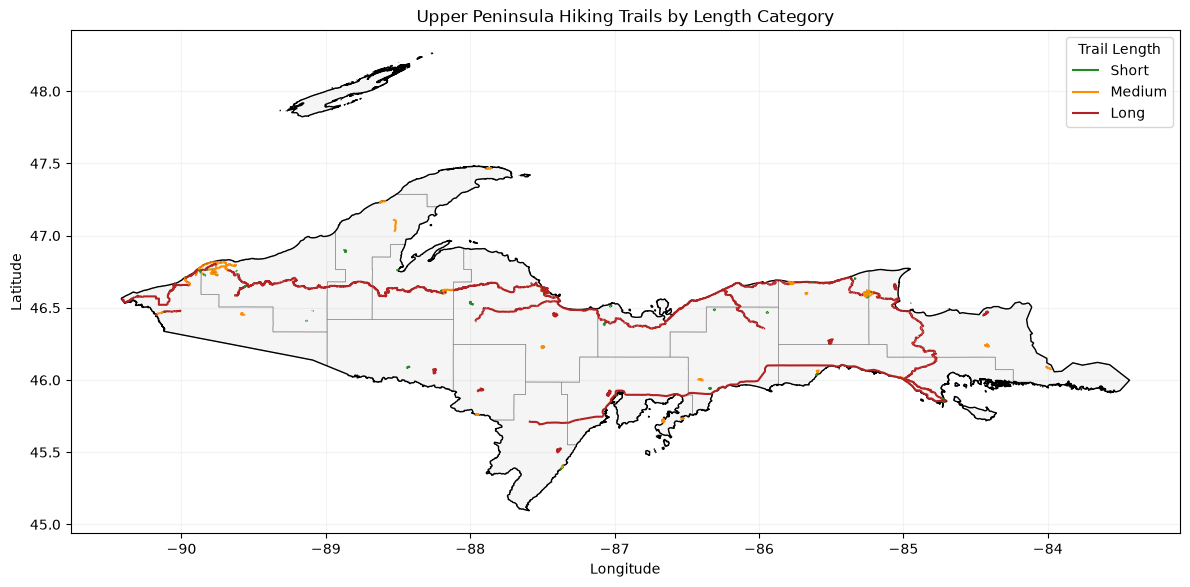

In [29]:
category_colors = {
    "Short": "forestgreen",
    "Medium": "darkorange",
    "Long": "firebrick",
}

# Confirm every layer uses the same CRS.
if up_counties.crs != trails.crs:
    up_counties = up_counties.to_crs(trails.crs)

fig, ax = plt.subplots(figsize=(12, 8))

# One filled Upper Peninsula shape.
up_outline.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="none",
    zorder=0,
)

# Very light internal county boundaries.
up_counties.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.5,
    alpha=0.7,
    zorder=1,
)

# Stronger exterior shoreline.
up_outline.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.0,
    zorder=2,
)

# Plot all three trail-length categories on the same map.
for category, color in category_colors.items():
    category_trails = trails[
        trails["LengthCategory"] == category
    ]

    category_trails.plot(
        ax=ax,
        color=color,
        linewidth=1.5,
        label=category,
        zorder=3,
    )

ax.set_title("Upper Peninsula Hiking Trails by Length Category")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Trail Length")
ax.set_aspect("equal")
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()